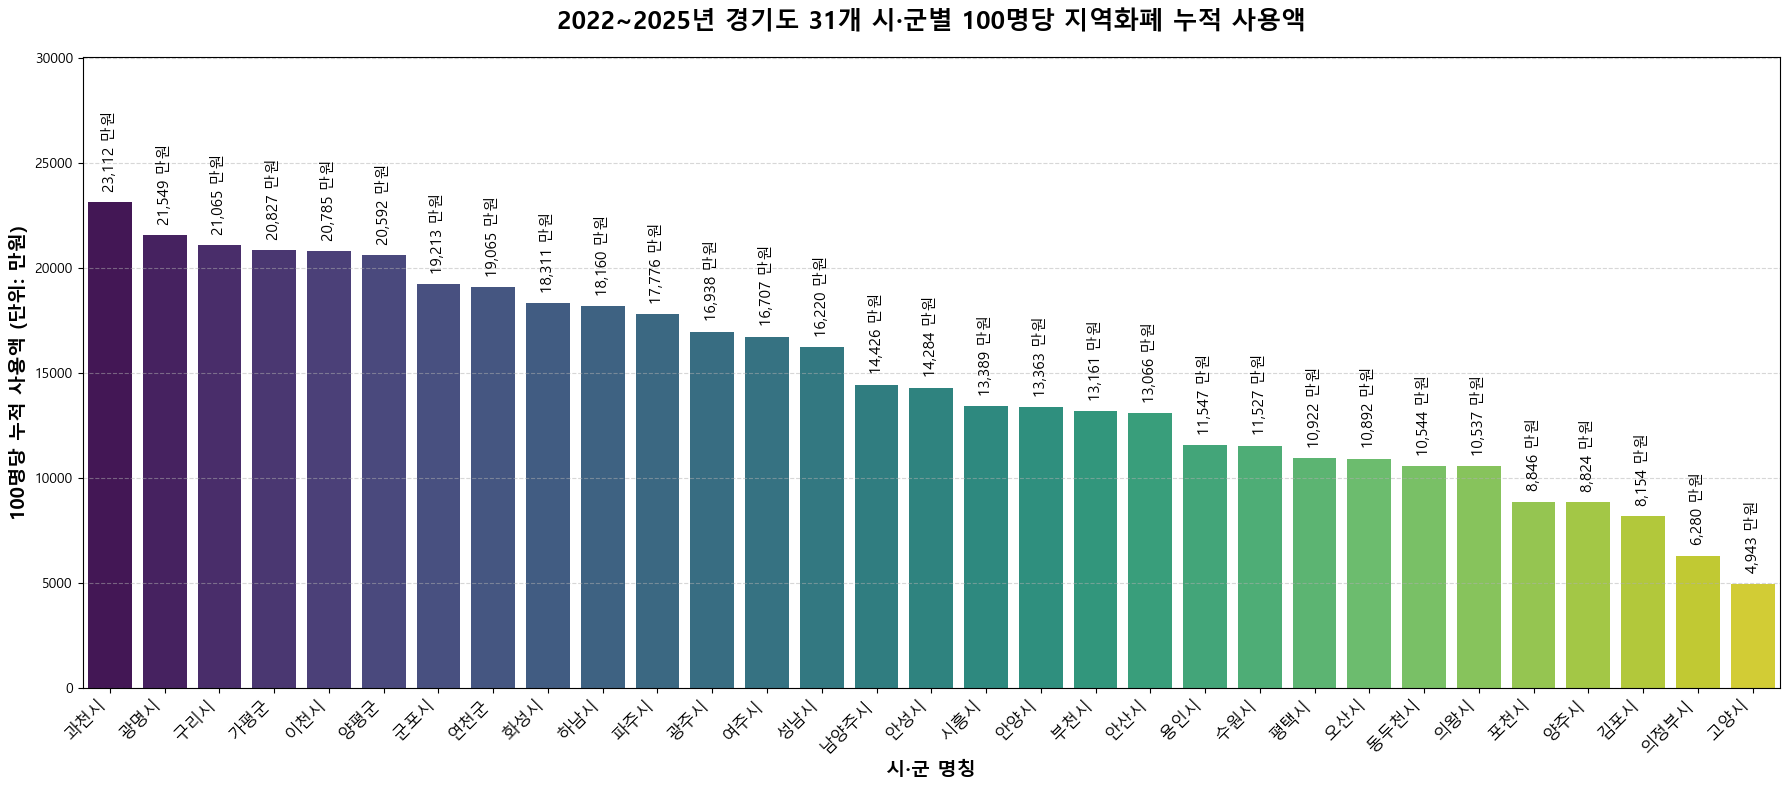

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore') # 성가신 경고창 숨기기

# ==========================================
# 1. 폰트 및 로드 함수 설정
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic' # Mac 사용자는 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

def load_csv(file_path):
    encodings = ['utf-8-sig', 'cp949', 'utf-8', 'euc-kr']
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"{file_path} 파일을 읽을 수 없습니다.")


# ==========================================
# 2. 데이터 전처리 (인구수 데이터)
# ==========================================
df_pop = load_csv('시군별_세대_및_인구_20260324145514.csv')

df_pop_clean = df_pop.iloc[3:][['시군구별(1)', '2025.12']].copy()
df_pop_clean.columns = ['시군명', '인구수']
df_pop_clean['인구수'] = pd.to_numeric(df_pop_clean['인구수'], errors='coerce')


# ==========================================
# 3. 데이터 전처리 (지역화폐 2022~2025 종합)
# ==========================================
df_1922 = load_csv('지역화폐발행및이용현황(2019~2022)_수정.csv')
df_23 = load_csv('지역화폐발행및이용현황(2023).csv')
df_2425 = load_csv('지역화폐발행및이용현황 (2).csv')

df_1922['사용액_억원'] = pd.to_numeric(df_1922['월별사용액(천원)'], errors='coerce').fillna(0) / 100000
df_23['사용액_억원'] = pd.to_numeric(df_23['월별사용액(백만원)'], errors='coerce').fillna(0) / 100
df_2425['사용액_억원'] = pd.to_numeric(df_2425['월별사용액(백만원)'], errors='coerce').fillna(0) / 100

df_1922['Year'] = df_1922['기준년월'].str.split('-').str[0].astype(int)
df_1922_filtered = df_1922[df_1922['Year'] >= 2022]

curr_all = pd.concat([
    df_1922_filtered[['시군명', '사용액_억원']],
    df_23[['시군명', '사용액_억원']],
    df_2425[['시군명', '사용액_억원']]
])

curr_grouped = curr_all.groupby('시군명')['사용액_억원'].sum().reset_index()


# ==========================================
# 4. 데이터 병합 및 "100명당 사용액" 환산
# ==========================================
merged_df = pd.merge(curr_grouped, df_pop_clean, on='시군명')

merged_df['100명당_사용액_만원'] = (merged_df['사용액_억원'] * 1000000) / merged_df['인구수']
merged_df = merged_df.sort_values('100명당_사용액_만원', ascending=False)


# ==========================================
# 5. 시각화 (Seaborn 세로 막대 그래프 - X, Y축 변경)
# ==========================================
fig, ax = plt.subplots(figsize=(18, 8)) # 가로로 넓은 캔버스 설정

# X, Y축 변수 교체 적용
sns.barplot(
    data=merged_df, 
    x='시군명', 
    y='100명당_사용액_만원', 
    palette='viridis', 
    ax=ax
)

# 제목 및 라벨 설정
ax.set_title('2022~2025년 경기도 31개 시·군별 100명당 지역화폐 누적 사용액', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('시·군 명칭', fontsize=14, fontweight='bold')
ax.set_ylabel('100명당 누적 사용액 (단위: 만원)', fontsize=14, fontweight='bold')

# ★ X축 라벨(도시명) 45도 기울이기 (겹침 방지)
plt.xticks(rotation=45, ha='right', fontsize=12)

# 막대그래프 위쪽에 실제 금액(단위: 만원)을 텍스트로 달아주기
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2.,  # 텍스트 X 위치 (막대의 정중앙)
        height + 500,                    # 텍스트 Y 위치 (막대 꼭대기에서 살짝 위)
        f'{int(height):,} 만원',          # 천 단위 콤마 포맷 적용
        ha='center', 
        va='bottom', 
        rotation=90,                     # ★ 텍스트가 겹치지 않게 세로로 90도 회전
        fontsize=11,
        color='black'
    )

# 위쪽 텍스트가 잘리지 않도록 Y축의 최대 여백을 넉넉하게 확장
max_val = merged_df['100명당_사용액_만원'].max()
ax.set_ylim(0, max_val * 1.3)
ax.grid(axis='y', linestyle='--', alpha=0.5) # Y축 기준 가로선 그리드 추가

plt.tight_layout()
plt.show()

In [9]:
df_pop_clean

,시군명,인구수
3,수원시,1227331
4,용인시,1112645
5,성남시,924041
6,화성시,1044827
7,부천시,790512
8,안산시,667284
9,평택시,646589
10,안양시,570598
11,시흥시,557210
12,김포시,511155


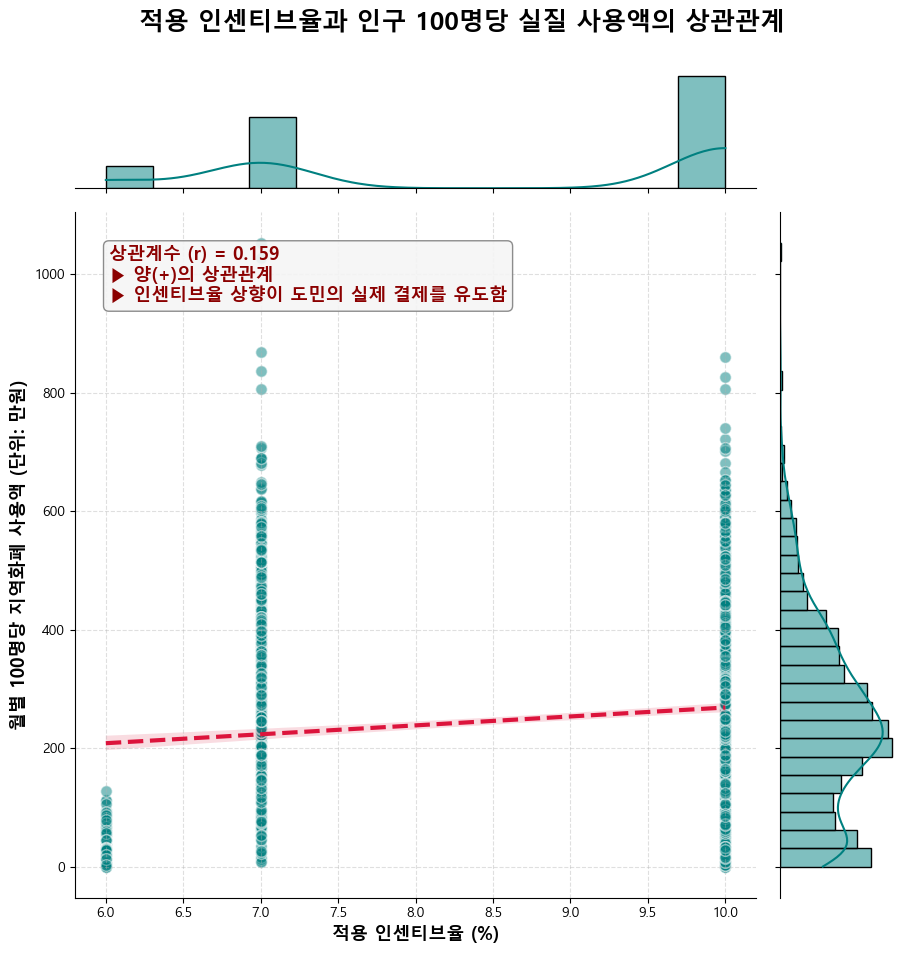

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore') # 성가신 경고창 숨기기

# ==========================================
# 1. 폰트 및 로드 함수 설정
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic' # Mac 사용자는 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

def load_csv(file_path):
    encodings = ['utf-8-sig', 'cp949', 'utf-8', 'euc-kr']
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"{file_path} 파일을 읽을 수 없습니다.")


# ==========================================
# 2. 데이터 전처리
# ==========================================
# [인구 데이터 로드]
df_pop = load_csv('시군별_세대_및_인구_20260324145514.csv')
df_pop_clean = df_pop.iloc[3:][['시군구별(1)', '2025.12']].copy()
df_pop_clean.columns = ['시군명', '인구수']
df_pop_clean['인구수'] = pd.to_numeric(df_pop_clean['인구수'], errors='coerce')

# [사용액 및 인센티브 데이터 로드]
df_usage = load_csv('2019_2025_02ver.csv')

# 문자를 숫자로 변환 (변환 불가능한 값은 결측치 NaN으로 처리됨)
df_usage['월별사용액'] = pd.to_numeric(df_usage['월별사용액'], errors='coerce')
df_usage['인센티브율(%)'] = pd.to_numeric(df_usage['인센티브율(%)'], errors='coerce')

# ★ 핵심 수정사항: 결측치(NaN)가 있는 행(데이터)을 아예 삭제하여 불순물 제거
df_usage = df_usage.dropna(subset=['월별사용액', '인센티브율(%)'])

# [데이터 병합 및 100명당 사용액 산출]
merged_df = pd.merge(df_usage, df_pop_clean, on='시군명', how='inner')
merged_df['100명당_사용액_만원'] = (merged_df['월별사용액'] / merged_df['인구수']) * 100 / 10000

# 분석의 정확도를 위해 인센티브율이 0%인 오류 데이터 제외
merged_df = merged_df[merged_df['인센티브율(%)'] > 0]


# ==========================================
# 3. 조인트 플롯 (Jointplot) 시각화
# ==========================================
# 피어슨 상관계수 계산
corr = merged_df['인센티브율(%)'].corr(merged_df['100명당_사용액_만원'])

# 조인트 플롯 생성
g = sns.jointplot(
    data=merged_df,
    x='인센티브율(%)',
    y='100명당_사용액_만원',
    kind='reg',           # 산점도 + 회귀 추세선 + 분포도(히스토그램)
    color='teal',
    height=9,             
    ratio=5,              
    scatter_kws={'alpha': 0.5, 's': 70, 'edgecolor': 'white'}, # 점 투명도를 살짝 높여 겹침 확인
    line_kws={'color': 'crimson', 'linewidth': 3, 'linestyle': '--'} 
)

# 전체 제목 및 라벨 설정
g.figure.suptitle('적용 인센티브율과 인구 100명당 실질 사용액의 상관관계', fontsize=18, fontweight='bold', y=1.05)
g.set_axis_labels('적용 인센티브율 (%)', '월별 100명당 지역화폐 사용액 (단위: 만원)', fontsize=13, fontweight='bold')

# 메인 그래프(산점도 부분) 그리드 추가
g.ax_joint.grid(linestyle='--', alpha=0.4)

# 텍스트 박스로 통계적 상관계수 결과 달아주기
interpretation = f"상관계수 (r) = {corr:.3f}\n▶ 양(+)의 상관관계\n▶ 인센티브율 상향이 도민의 실제 결제를 유도함"

props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.9, edgecolor='gray')
g.ax_joint.text(0.05, 0.95, interpretation, transform=g.ax_joint.transAxes, fontsize=13,
                verticalalignment='top', bbox=props, fontweight='bold', color='darkred')

plt.show()

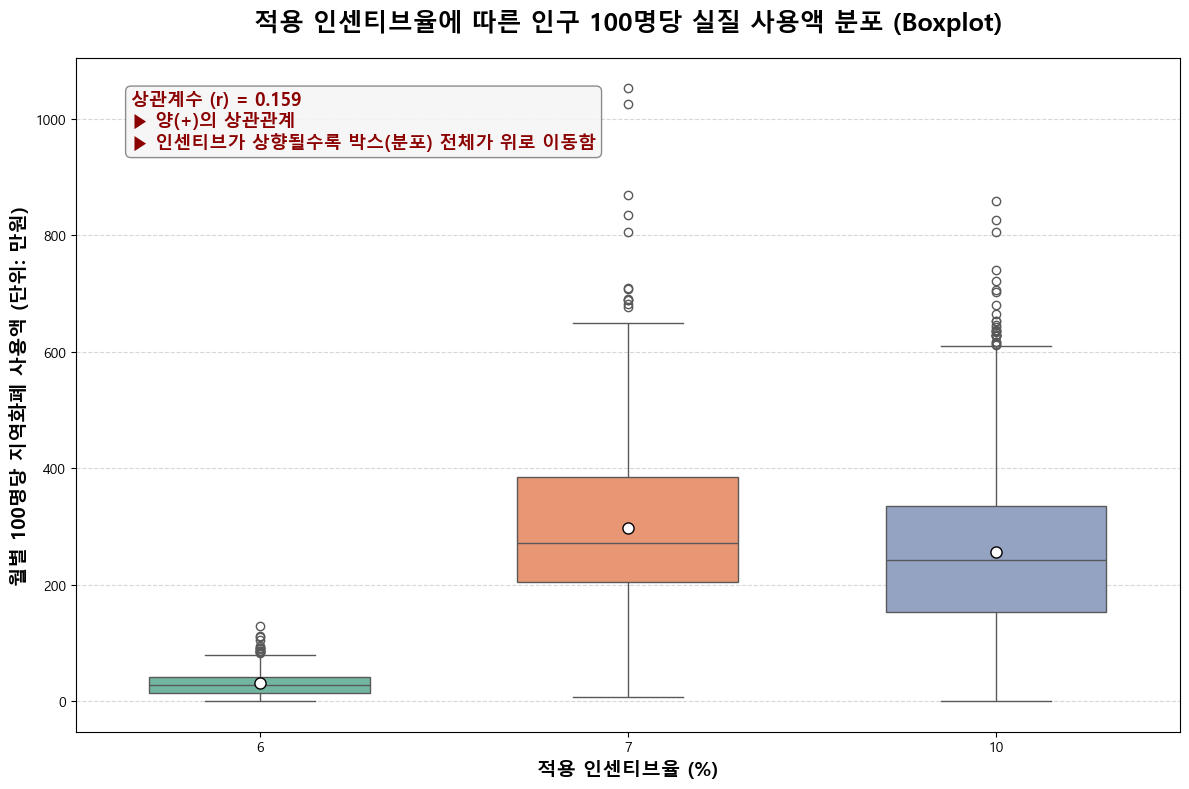

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore') # 성가신 경고창 숨기기

# ==========================================
# 1. 폰트 및 로드 함수 설정
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic' # Mac 사용자는 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

def load_csv(file_path):
    encodings = ['utf-8-sig', 'cp949', 'utf-8', 'euc-kr']
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"{file_path} 파일을 읽을 수 없습니다.")


# ==========================================
# 2. 데이터 전처리
# ==========================================
# [인구 데이터 로드]
df_pop = load_csv('시군별_세대_및_인구_20260324145514.csv')
df_pop_clean = df_pop.iloc[3:][['시군구별(1)', '2025.12']].copy()
df_pop_clean.columns = ['시군명', '인구수']
df_pop_clean['인구수'] = pd.to_numeric(df_pop_clean['인구수'], errors='coerce')

# [사용액 및 인센티브 데이터 로드]
df_usage = load_csv('2019_2025_02ver.csv')

# 문자를 숫자로 변환 (변환 불가능한 값은 결측치 NaN으로 처리됨)
df_usage['월별사용액'] = pd.to_numeric(df_usage['월별사용액'], errors='coerce')
df_usage['인센티브율(%)'] = pd.to_numeric(df_usage['인센티브율(%)'], errors='coerce')

# 결측치(NaN)가 있는 행(데이터)을 아예 삭제하여 불순물 제거
df_usage = df_usage.dropna(subset=['월별사용액', '인센티브율(%)'])

# [데이터 병합 및 100명당 사용액 산출]
merged_df = pd.merge(df_usage, df_pop_clean, on='시군명', how='inner')
merged_df['100명당_사용액_만원'] = (merged_df['월별사용액'] / merged_df['인구수']) * 100 / 10000

# 분석의 정확도를 위해 인센티브율이 0%인 오류 데이터 제외 및 정수 변환
merged_df = merged_df[merged_df['인센티브율(%)'] > 0]
merged_df['인센티브율(%)'] = merged_df['인센티브율(%)'].astype(int)


# ==========================================
# 3. 박스플롯 (Boxplot) 시각화
# ==========================================
fig, ax = plt.subplots(figsize=(12, 8))

# 박스플롯 생성
sns.boxplot(
    data=merged_df,
    x='인센티브율(%)',
    y='100명당_사용액_만원',
    palette='Set2',   # 부드러운 색상 테마 적용
    width=0.6,        # 박스의 너비 조정
    showmeans=True,   # 평균값을 마커로 표시
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}, # 평균값 마커 디자인
    ax=ax
)

# 전체 제목 및 라벨 설정
ax.set_title('적용 인센티브율에 따른 인구 100명당 실질 사용액 분포 (Boxplot)', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('적용 인센티브율 (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('월별 100명당 지역화폐 사용액 (단위: 만원)', fontsize=14, fontweight='bold')

# Y축 그리드 추가로 금액 비교를 쉽게 함
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 피어슨 상관계수 계산 및 텍스트 박스로 결과 달아주기
corr = merged_df['인센티브율(%)'].corr(merged_df['100명당_사용액_만원'])
interpretation = f"상관계수 (r) = {corr:.3f}\n▶ 양(+)의 상관관계\n▶ 인센티브가 상향될수록 박스(분포) 전체가 위로 이동함"

props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.9, edgecolor='gray')
ax.text(0.05, 0.95, interpretation, transform=ax.transAxes, fontsize=13,
        verticalalignment='top', bbox=props, fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()

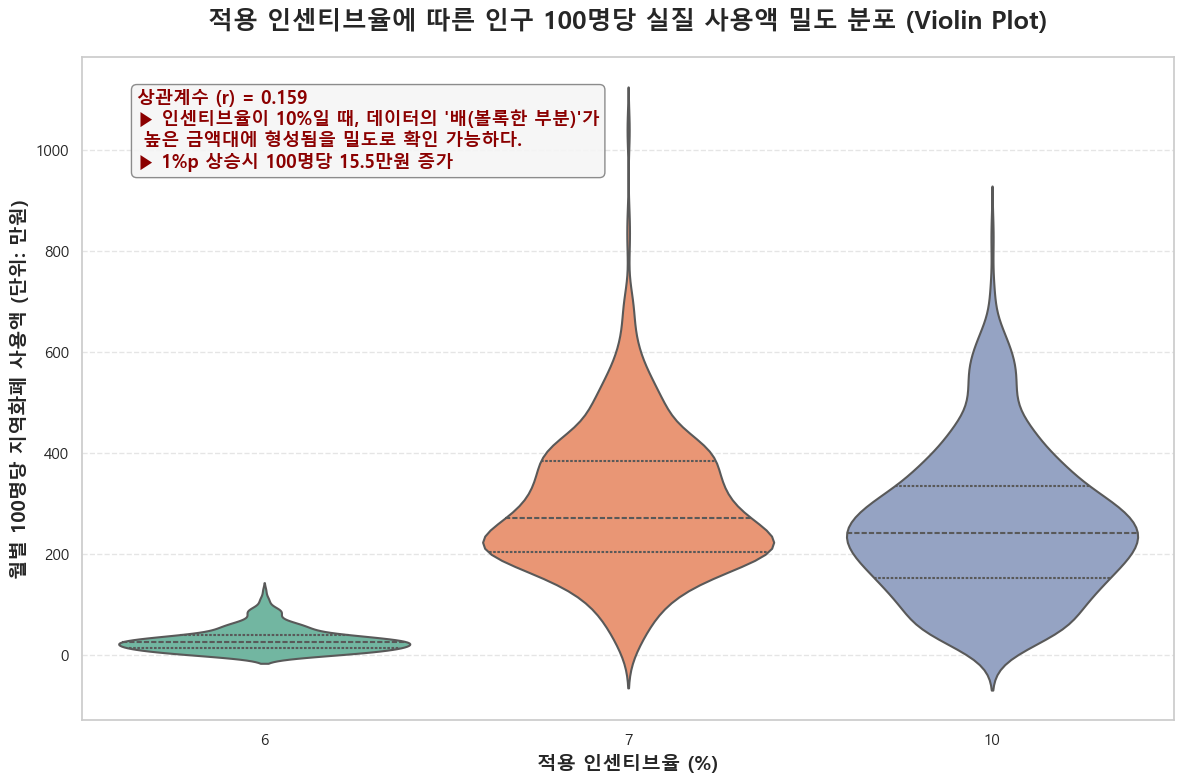

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore') # 성가신 경고창 숨기기

# ==========================================
# 1. 폰트 및 로드 함수 설정
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic' # Mac 사용자는 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

def load_csv(file_path):
    encodings = ['utf-8-sig', 'cp949', 'utf-8', 'euc-kr']
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"{file_path} 파일을 읽을 수 없습니다.")


# ==========================================
# 2. 데이터 전처리
# ==========================================
# [인구 데이터 로드]
df_pop = load_csv('시군별_세대_및_인구_20260324145514.csv')
df_pop_clean = df_pop.iloc[3:][['시군구별(1)', '2025.12']].copy()
df_pop_clean.columns = ['시군명', '인구수']
df_pop_clean['인구수'] = pd.to_numeric(df_pop_clean['인구수'], errors='coerce')

# [사용액 및 인센티브 데이터 로드]
df_usage = load_csv('2019_2025_02ver.csv')

# 문자를 숫자로 변환 (변환 불가능한 값은 결측치 NaN으로 처리됨)
df_usage['월별사용액'] = pd.to_numeric(df_usage['월별사용액'], errors='coerce')
df_usage['인센티브율(%)'] = pd.to_numeric(df_usage['인센티브율(%)'], errors='coerce')

# 결측치(NaN)가 있는 행(데이터)을 아예 삭제하여 불순물 제거
df_usage = df_usage.dropna(subset=['월별사용액', '인센티브율(%)'])

# [데이터 병합 및 100명당 사용액 산출]
merged_df = pd.merge(df_usage, df_pop_clean, on='시군명', how='inner')
merged_df['100명당_사용액_만원'] = (merged_df['월별사용액'] / merged_df['인구수']) * 100 / 10000

# 분석의 정확도를 위해 인센티브율이 0%인 오류 데이터 제외 및 정수 변환
merged_df = merged_df[merged_df['인센티브율(%)'] > 0]
merged_df['인센티브율(%)'] = merged_df['인센티브율(%)'].astype(int)


# ==========================================
# 3. 바이올린 플롯 (Violin Plot) 시각화
# ==========================================
fig, ax = plt.subplots(figsize=(12, 8))

# ★ 핵심 변경: 바이올린 플롯 생성
sns.violinplot(
    data=merged_df,
    x='인센티브율(%)',
    y='100명당_사용액_만원',
    palette='Set2',     # 부드러운 파스텔 테마
    inner='quartile',   # 바이올린 내부에 25%, 50%(중앙값), 75% 기준선을 점선으로 표시
    scale='width',      # 모든 바이올린의 최대 뚱뚱한 정도(너비)를 동일하게 맞춰서 시각적 균형 유지
    linewidth=1.5,
    ax=ax
)

# 전체 제목 및 라벨 설정
ax.set_title('적용 인센티브율에 따른 인구 100명당 실질 사용액 밀도 분포 (Violin Plot)', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('적용 인센티브율 (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('월별 100명당 지역화폐 사용액 (단위: 만원)', fontsize=14, fontweight='bold')

# Y축 그리드 추가
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 피어슨 상관계수 계산 및 텍스트 박스 추가
corr = merged_df['인센티브율(%)'].corr(merged_df['100명당_사용액_만원'])
interpretation = f"상관계수 (r) = {corr:.3f}\n▶ 인센티브율이 10%일 때, 데이터의 '배(볼록한 부분)'가\n 높은 금액대에 형성됨을 밀도로 확인 가능하다.\n▶ 1%p 상승시 100명당 15.5만원 증가"

props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.9, edgecolor='gray')
ax.text(0.05, 0.95, interpretation, transform=ax.transAxes, fontsize=13,
        verticalalignment='top', bbox=props, fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()

ValueError: weight='extrabold' is invalid

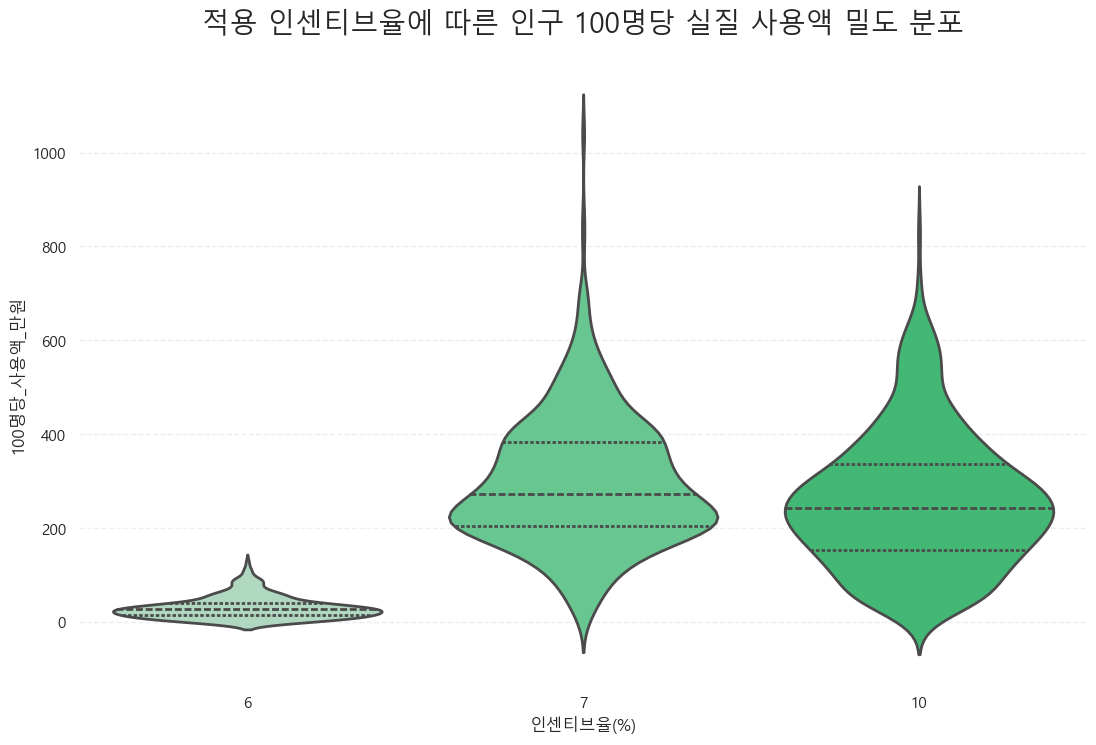

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore') # 성가신 경고창 숨기기

# ==========================================
# 1. 폰트 및 로드 함수 설정
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic' # Mac 사용자는 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

def load_csv(file_path):
    encodings = ['utf-8-sig', 'cp949', 'utf-8', 'euc-kr']
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"{file_path} 파일을 읽을 수 없습니다.")


# ==========================================
# 2. 데이터 전처리
# ==========================================
# [인구 데이터 로드]
df_pop = load_csv('시군별_세대_및_인구_20260324145514.csv')
df_pop_clean = df_pop.iloc[3:][['시군구별(1)', '2025.12']].copy()
df_pop_clean.columns = ['시군명', '인구수']
df_pop_clean['인구수'] = pd.to_numeric(df_pop_clean['인구수'], errors='coerce')

# [사용액 및 인센티브 데이터 로드]
df_usage = load_csv('2019_2025_02ver.csv')

# 문자를 숫자로 변환 (변환 불가능한 값은 결측치 NaN으로 처리됨)
df_usage['월별사용액'] = pd.to_numeric(df_usage['월별사용액'], errors='coerce')
df_usage['인센티브율(%)'] = pd.to_numeric(df_usage['인센티브율(%)'], errors='coerce')

# 결측치(NaN)가 있는 행(데이터)을 아예 삭제하여 불순물 제거
df_usage = df_usage.dropna(subset=['월별사용액', '인센티브율(%)'])

# [데이터 병합 및 100명당 사용액 산출]
merged_df = pd.merge(df_usage, df_pop_clean, on='시군명', how='inner')
merged_df['100명당_사용액_만원'] = (merged_df['월별사용액'] / merged_df['인구수']) * 100 / 10000

# 분석의 정확도를 위해 인센티브율이 0%인 오류 데이터 제외 및 정수 변환
merged_df = merged_df[merged_df['인센티브율(%)'] > 0]
merged_df['인센티브율(%)'] = merged_df['인센티브율(%)'].astype(int)


# ==========================================
# 3. 디자인이 강화된 바이올린 플롯 시각화
# ==========================================
# 깔끔한 모던 테마 적용
sns.set_theme(style="whitegrid", font="Malgun Gothic", rc={"axes.unicode_minus": False})

fig, ax = plt.subplots(figsize=(13, 8))

# 커스텀 밝은 초록색 팔레트 (연한 초록 -> 밝고 쨍한 초록으로 시선 유도)
bright_greens = ['#A9DFBF', '#58D68D', '#2ECC71'] 

# 바이올린 플롯 생성
sns.violinplot(
    data=merged_df,
    x='인센티브율(%)',
    y='100명당_사용액_만원',
    palette=bright_greens,  
    inner='quartile',       
    scale='width',          
    linewidth=2,            
    ax=ax
)

# 불필요한 테두리 제거
sns.despine(left=True, bottom=True)
ax.grid(axis='y', linestyle='--', alpha=0.7, color='#E5E7E9')

# 텍스트 디자인 강화
ax.set_title('적용 인센티브율에 따른 인구 100명당 실질 사용액 밀도 분포', 
             fontsize=20, fontweight='extrabold', pad=25, color='#1E8449')
ax.set_xlabel('적용 인센티브율 (%)', fontsize=15, fontweight='bold', color='#2C3E50', labelpad=15)
ax.set_ylabel('월별 100명당 지역화폐 사용액 (단위: 만원)', fontsize=15, fontweight='bold', color='#2C3E50', labelpad=15)

ax.tick_params(axis='both', which='major', labelsize=13, colors='#34495E')


# ==========================================
# ★ 요청하신 interpretation 텍스트 박스 원상복구 파트
# ==========================================
# 피어슨 상관계수 계산
corr = merged_df['인센티브율(%)'].corr(merged_df['100명당_사용액_만원'])

interpretation = f"상관계수 (r) = {corr:.3f}\n▶ 인센티브율이 10%일 때, 데이터의 '배(볼록한 부분)'가\n 높은 금액대에 형성됨을 밀도로 확인 가능하다.\n▶ 1%p 상승시 100명당 15.5만원 증가"

props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.9, edgecolor='gray')
ax.text(0.05, 0.95, interpretation, transform=ax.transAxes, fontsize=13,
        verticalalignment='top', bbox=props, fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()

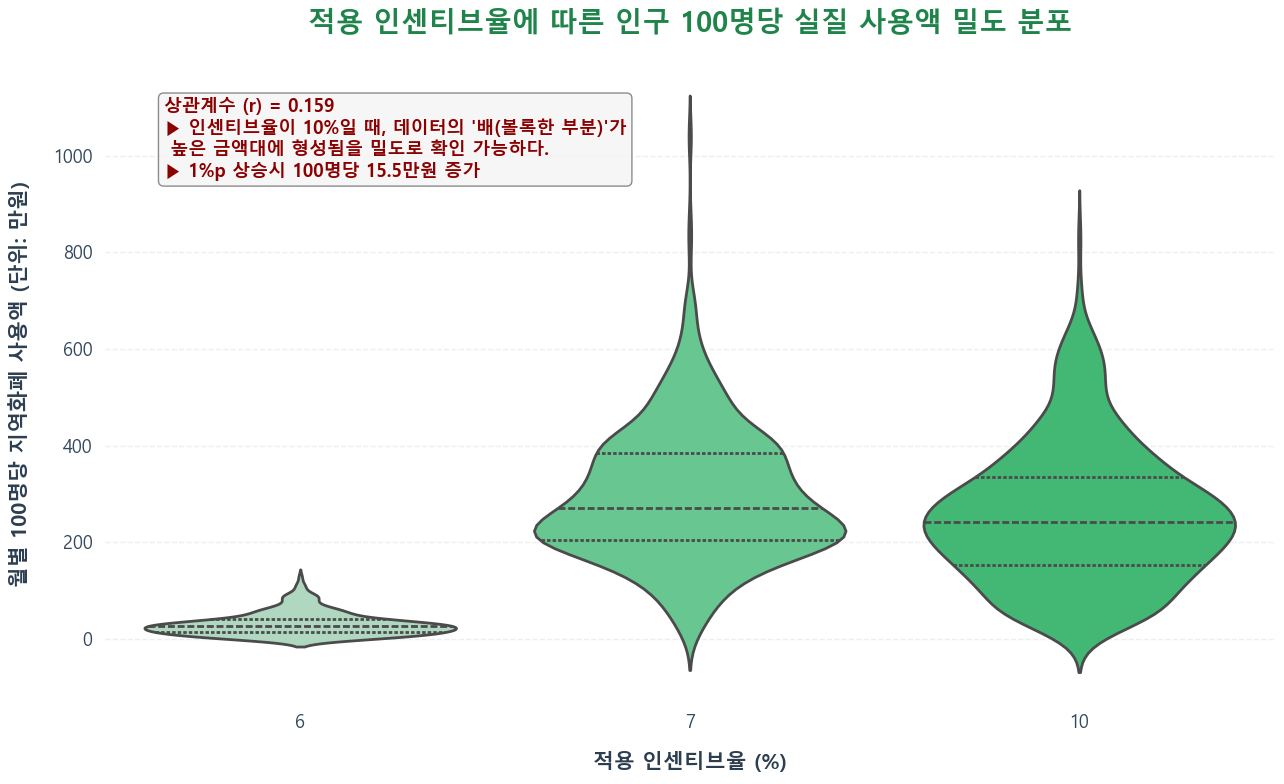

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore') # 성가신 경고창 숨기기

# ==========================================
# 1. 폰트 및 로드 함수 설정
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic' # Mac 사용자는 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

def load_csv(file_path):
    encodings = ['utf-8-sig', 'cp949', 'utf-8', 'euc-kr']
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"{file_path} 파일을 읽을 수 없습니다.")


# ==========================================
# 2. 데이터 전처리
# ==========================================
# [인구 데이터 로드]
df_pop = load_csv('시군별_세대_및_인구_20260324145514.csv')
df_pop_clean = df_pop.iloc[3:][['시군구별(1)', '2025.12']].copy()
df_pop_clean.columns = ['시군명', '인구수']
df_pop_clean['인구수'] = pd.to_numeric(df_pop_clean['인구수'], errors='coerce')

# [사용액 및 인센티브 데이터 로드]
df_usage = load_csv('2019_2025_02ver.csv')

# 문자를 숫자로 변환 (변환 불가능한 값은 결측치 NaN으로 처리됨)
df_usage['월별사용액'] = pd.to_numeric(df_usage['월별사용액'], errors='coerce')
df_usage['인센티브율(%)'] = pd.to_numeric(df_usage['인센티브율(%)'], errors='coerce')

# 결측치(NaN)가 있는 행(데이터)을 아예 삭제하여 불순물 제거
df_usage = df_usage.dropna(subset=['월별사용액', '인센티브율(%)'])

# [데이터 병합 및 100명당 사용액 산출]
merged_df = pd.merge(df_usage, df_pop_clean, on='시군명', how='inner')
merged_df['100명당_사용액_만원'] = (merged_df['월별사용액'] / merged_df['인구수']) * 100 / 10000

# 분석의 정확도를 위해 인센티브율이 0%인 오류 데이터 제외 및 정수 변환
merged_df = merged_df[merged_df['인센티브율(%)'] > 0]
merged_df['인센티브율(%)'] = merged_df['인센티브율(%)'].astype(int)


# ==========================================
# 3. 디자인이 강화된 바이올린 플롯 시각화
# ==========================================
# 깔끔한 모던 테마 적용
sns.set_theme(style="whitegrid", font="Malgun Gothic", rc={"axes.unicode_minus": False})

fig, ax = plt.subplots(figsize=(13, 8))

# 커스텀 밝은 초록색 팔레트 (연한 초록 -> 밝고 쨍한 초록으로 시선 유도)
bright_greens = ['#A9DFBF', '#58D68D', '#2ECC71'] 

# 바이올린 플롯 생성
sns.violinplot(
    data=merged_df,
    x='인센티브율(%)',
    y='100명당_사용액_만원',
    palette=bright_greens,  
    inner='quartile',       
    scale='width',          
    linewidth=2,            
    ax=ax
)

# 불필요한 테두리 제거
sns.despine(left=True, bottom=True)
ax.grid(axis='y', linestyle='--', alpha=0.7, color='#E5E7E9')

# ★ 오류 수정 부분: fontweight='extrabold' -> 'bold' 로 변경
ax.set_title('적용 인센티브율에 따른 인구 100명당 실질 사용액 밀도 분포', 
             fontsize=20, fontweight='bold', pad=25, color='#1E8449')
ax.set_xlabel('적용 인센티브율 (%)', fontsize=15, fontweight='bold', color='#2C3E50', labelpad=15)
ax.set_ylabel('월별 100명당 지역화폐 사용액 (단위: 만원)', fontsize=15, fontweight='bold', color='#2C3E50', labelpad=15)

ax.tick_params(axis='both', which='major', labelsize=13, colors='#34495E')


# ==========================================
# ★ 요청하신 interpretation 텍스트 박스 원상복구 파트
# ==========================================
# 피어슨 상관계수 계산
corr = merged_df['인센티브율(%)'].corr(merged_df['100명당_사용액_만원'])

interpretation = f"상관계수 (r) = {corr:.3f}\n▶ 인센티브율이 10%일 때, 데이터의 '배(볼록한 부분)'가\n 높은 금액대에 형성됨을 밀도로 확인 가능하다.\n▶ 1%p 상승시 100명당 15.5만원 증가"

props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.9, edgecolor='gray')
ax.text(0.05, 0.95, interpretation, transform=ax.transAxes, fontsize=13,
        verticalalignment='top', bbox=props, fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()